In [1]:
import sys
from pathlib import Path

import matplotlib as mpl

In [2]:
class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [3]:
import src.compute.stats as stats_module
# from data import b_naive, b_memory

import importlib
import src.plot.tracks.reconstruct as reconstruct_module
import src.batch.tree as batch_tree_module
import src.io.load as load_module
import src.filter.filters as filters_module

In [4]:
importlib.reload(load_module)

load_data = load_module.load_data

data = load_data(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\mem_cxcl12\#memory-cxcl12#BC39#Stablized_spots.csv", retain=['POSITION_Z'], split_filename=True, split_filename_delimiter='#', split_filename_position=2)

In [5]:
importlib.reload(stats_module)

stats = stats_module.stats

spots = stats.spots(data)
spots

,track_id,time_point,x_coordinate,y_coordinate,POSITION_Z,set,frame,distance,cum_track_length,cum_track_displacement,...,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
track_uid,,,,,,,,,,,,,,,,,,,,,
0,196.0,0.0,446.049935,514.718016,0.0,BC39,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,46.0,0.0,105.142437,265.404884,0.0,BC39,0,422.344599,4.223446e+02,422.344599,...,NaN,3.519538,NaN,-2.510153,NaN,NaN,NaN,NaN,-2.510153,0.000000
0,193.0,0.0,57.339646,514.234949,0.0,BC39,0,253.380165,6.757248e+02,388.710589,...,NaN,2.159503,NaN,1.760594,115.304209,1.153042e+02,115.304209,0.640579,2.766813,0.464941
0,199.0,0.0,533.838219,533.021939,0.0,BC39,0,476.868789,1.152594e+03,89.676176,...,NaN,0.373651,NaN,0.039407,98.616773,2.139210e+02,106.960491,0.445669,1.562946,0.856285
0,198.0,0.0,962.196674,538.272284,0.0,BC39,0,428.390630,1.580984e+03,516.683907,...,NaN,1.722280,NaN,0.012256,1.555608,2.154766e+02,71.825530,0.239418,0.416118,0.725771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,723.0,3540.0,11.838741,321.551650,0.0,BC39,59,399.540816,1.219409e+07,475.239524,...,3444.657704,0.000326,9.455563e-08,2.625023,25.926157,2.900973e+06,119.303046,0.000082,-2.235701,0.996397
0,727.0,3540.0,41.932501,675.383134,0.0,BC39,59,355.108932,1.219444e+07,434.884100,...,3444.758017,0.000298,8.652027e-08,1.485949,65.264125,2.901038e+06,119.300824,0.000082,-2.242017,0.996432
0,726.0,3540.0,17.251840,588.025299,0.0,BC39,59,90.777345,1.219453e+07,435.019268,...,3444.783661,0.000298,8.654295e-08,-1.846144,169.085126,2.901207e+06,119.302871,0.000082,-2.237620,0.996394


In [6]:
importlib.reload(stats_module)

stats = stats_module.stats

tracks = stats.tracks(spots)
tracks

,set,track_id,POSITION_Z,track_length,speed_min,speed_max,speed_mean,speed_sd,speed_median,x_location,...,track_end_time,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_displacement,straightness_ratio,track_points
track_uid,,,,,,,,,,,,,,,,,,,,,
0,BC39,196.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,46.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,193.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,199.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,198.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,BC39,727.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,723.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,730.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322


In [7]:
importlib.reload(filters_module)

filter = filters_module.filter

Dropping 366 rows with non-finite 'Track displacement'/'Speed sd' values


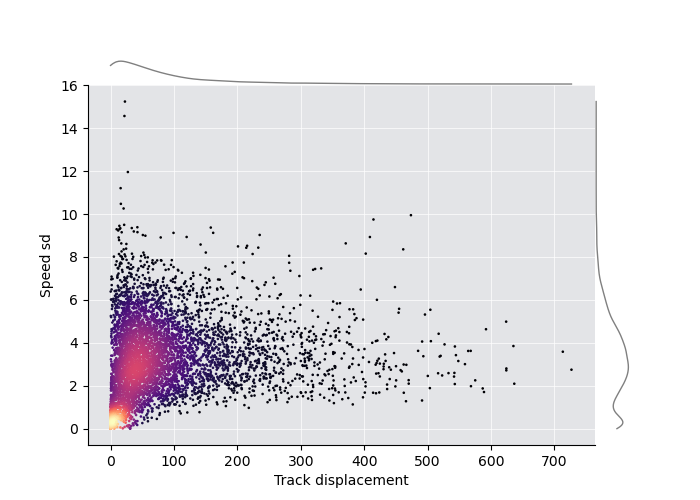

<module 'matplotlib.pyplot' from 'c:\\Users\\modri\\miniconda3\\envs\\peregrin\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [71]:
%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

from matplotlib.widgets import Cursor

df = pd.read_csv(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\Track stats 2026-02-22.csv")

class Gating:

    def __init__(self):
        np.random.seed(42)

        self.df: pd.DataFrame = None


    def gate(
        self,
        df: pd.DataFrame,
        y: str,
        x: str,
        **kwargs
    ) -> None:
        
        if self.df is None:
            self.df = df

        if kwargs.get("sample_fraction", None) is not None:
            if not isinstance(kwargs["sample_fraction"], float) or not (0 < kwargs["sample_fraction"] <= 1):
                raise ValueError("sample_fraction must be a float between 0 and 1")
            df = df.sample(frac=kwargs["sample_fraction"]).reset_index(drop=True)
        else:
            if len(df) > 10000:
                df = df.sample(n=10000).reset_index(drop=True)

        xdata = df[x].to_numpy(float)
        ydata = df[y].to_numpy(float)

        # drop rows with NaN (or inf) in either coordinate
        finite = np.isfinite(xdata) & np.isfinite(ydata)
        n_dropped = int((~finite).sum())
        if n_dropped:
            print(f"Dropping {n_dropped} rows with non-finite {x!r}/{y!r} values")
        df = df.loc[finite].reset_index(drop=True)
        xdata = xdata[finite]
        ydata = ydata[finite]
        # xy = np.column_stack([xdata, ydata])


        # compute local point density (count) via Gaussian KDE
        density = gaussian_kde(np.vstack([xdata, ydata]))(np.vstack([xdata, ydata]))

        # sort so densest points are drawn on top
        order = density.argsort()
        xs, ys, dens = xdata[order], ydata[order], density[order]

        fig, ax = plt.subplots(figsize=(7, 5))
        pts = ax.scatter(xs, ys, c=dens, s=0.75, cmap=kwargs.get("cmap", "magma"), zorder=3)
        ax.set_xlabel(x)
        ax.set_ylabel(y)

        for axis in ["top", "right"]:
            ax.spines[axis].set_visible(False)

        # --- marginal KDE plots on the top (x) and right (y) axes ---
        divider = make_axes_locatable(ax)
        ax_top = divider.append_axes("top", size="7%", pad=0, sharex=ax)
        ax_right = divider.append_axes("right", size="7%", pad=0, sharey=ax)

        _c  = "#0b0205"
        _c = 'grey'
        _lw = 1

        kde_x = gaussian_kde(xdata)
        x_grid = np.linspace(xdata.min(), xdata.max(), 400)
        x_dens = kde_x(x_grid)
        ax_top.plot(x_grid, x_dens, color=_c, lw=_lw)
        ax_top.set_axis_off()

        # y marginal (right)
        kde_y = gaussian_kde(ydata)
        y_grid = np.linspace(ydata.min(), ydata.max(), 400)
        y_dens = kde_y(y_grid)
        ax_right.plot(y_dens, y_grid, color=_c, lw=_lw)
        ax_right.set_axis_off()

        # store the density-based facecolors so we can restore them after gating
        base_colors = pts.get_facecolors().copy()

        # store selection so you can use it in later cells
        selection = {"mask": None, "verts": None, "df": None}

        _color = '#002fff'
        _color2 = "#002fff4b"

        # Set useblit=True on most backends for enhanced performance.
        # Keep a reference on fig so the crosshair survives across cells.
        fig._cursor = Cursor(
            ax,
            useblit=True,
            color=_color2,
            linewidth=1,
            horizOn=True,
            vertOn=True,
        )

        def on_select(verts):
            path = Path(verts)
            inside = path.contains_points(np.column_stack([xs, ys]))
            colors = base_colors.copy()
            pts.set_facecolors(colors)
            fig.canvas.draw_idle()
            selection["mask"] = inside
            selection["verts"] = verts
            # keep the gated DataFrame up to date on every change
            selection["df"] = df.loc[inside].reset_index(drop=True)
            print(f"{inside.sum()} points inside gate")

        
        ax.set_facecolor("#e3e4e7")
        ax.grid(True, color="white", linewidth=0.5, zorder=0)

        # keep a reference on fig so it survives across cells
        fig._poly_selector = PolygonSelector(
            ax, 
            on_select, 
            useblit=True, 
            props=dict(
                color=_color,
                lw=1.25,
                zorder=99999
            ),
            handle_props=dict(
                markeredgecolor=_color,
                markerfacecolor='white',
                alpha=1,
                zorder=99999
            )
        )

        plt.show()

        self.selection = selection

        return plt
    

    def get_selection(self) -> dict:
        if not hasattr(self, "selection"):
            raise RuntimeError("No selection available. Please run gate() first.")
        return self.selection


Filter = Gating()

Filter.gate(
    df=df,
    y="Speed sd",
    x="Track displacement"
)

In [76]:
Filter.get_selection()['df']
len(Filter.get_selection()['df'])

1

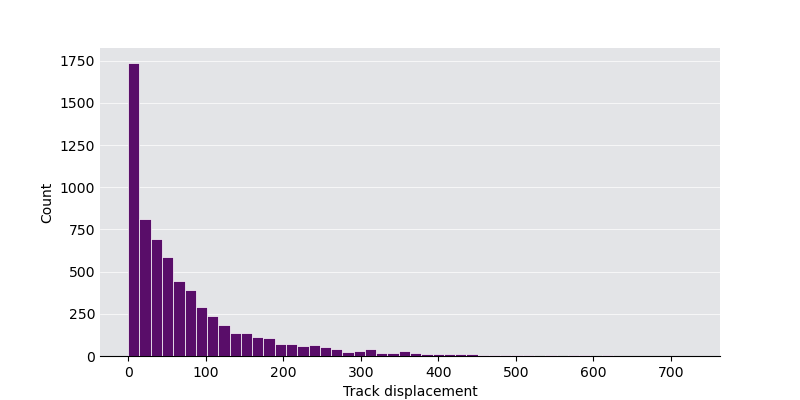

In [169]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import SpanSelector

# color = '#6100a7'
color = "#590d69"

# Fixing random state for reproducibility
np.random.seed(42)

def threshold_selector_demo(
    df, 
    metric,
    **kwargs
):

    fig, ax = plt.subplots(figsize=(8, 4))

    data = df[metric].to_numpy(float)
    data = data[np.isfinite(data)]

    # draw the histogram
    counts, bins, patches = ax.hist(
        data,
        bins=kwargs.get("bins", "auto"),
        color=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=3
    )
    ax.set_xlabel(metric)
    ax.set_ylabel("Count")

    for axis in ["left", "top", "right"]:
        ax.spines[axis].set_visible(False)

    ax.tick_params(axis="y", which="both", length=0)   

    ax.set_facecolor("#e3e4e7")
    ax.grid(True, axis="y", color="white", linewidth=0.5, zorder=0)

    # store the current selection so it can be used in later cells
    selection = {"min": None, "max": None, "mask": None, "df": None}

    def onselect(xmin, xmax):
        # guard against a zero-width (single click) selection
        if xmin == xmax:
            selection.update({"min": None, "max": None, "mask": None, "df": None})
            return

        mask = (data >= xmin) & (data <= xmax)

        # recolor bars: highlight those within the selected range
        for patch, left_edge, right_edge in zip(patches, bins[:-1], bins[1:]):
            center = 0.5 * (left_edge + right_edge)
            if xmin <= center <= xmax:
                patch.set_facecolor(color)
            else:
                patch.set_facecolor("darkgrey")

        selection["min"] = xmin
        selection["max"] = xmax
        selection["mask"] = (df[metric].to_numpy(float) >= xmin) & (
            df[metric].to_numpy(float) <= xmax
        )
        selection["df"] = df.loc[selection["mask"]].reset_index(drop=True)

        fig.canvas.draw_idle()
        print(f"{mask.sum()} values in range [{xmin:.4g}, {xmax:.4g}]")

    span = SpanSelector(
        ax,
        onselect,
        "horizontal",
        useblit=True,
        interactive=True,
        drag_from_anywhere=True,
        props=dict(
            alpha=0.25, 
            facecolor="#7E7EE9",
            zorder=2
        ),
        handle_props=dict(
            color='#002fff',
            zorder=99999
        )
    )
    # Set useblit=True on most backends for enhanced performance.

    # keep references alive so the widget survives across cells
    fig._span_selector = span
    threshold_selector_demo.selection = selection

    plt.show()

    return selection


selection = threshold_selector_demo(df, metric="Track displacement", bins=50)

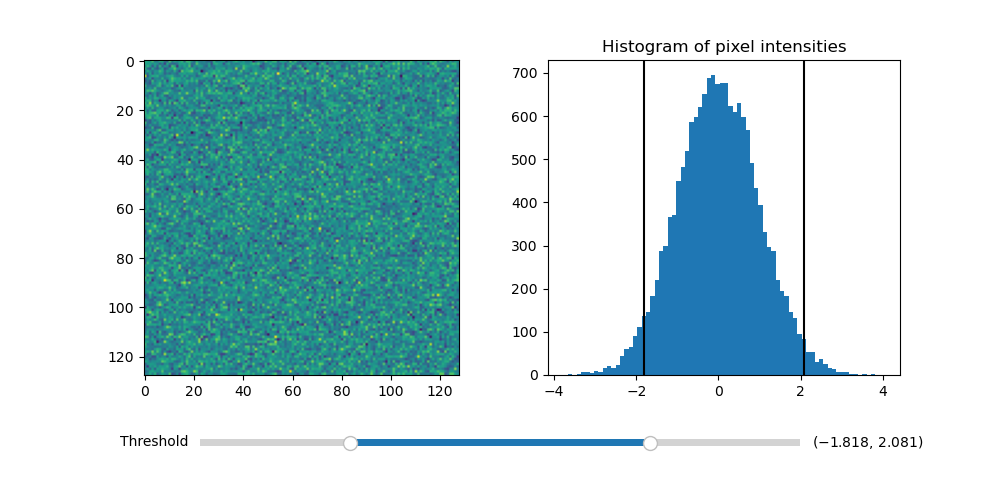

In [101]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import RangeSlider

# generate a fake image
np.random.seed(19680801)
N = 128
img = np.random.randn(N, N)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(bottom=0.25)

im = axs[0].imshow(img)
axs[1].hist(img.flatten(), bins='auto')
axs[1].set_title('Histogram of pixel intensities')

# Create the RangeSlider
slider_ax = fig.add_axes((0.20, 0.1, 0.60, 0.03))
slider = RangeSlider(slider_ax, "Threshold", img.min(), img.max())

# Create the Vertical lines on the histogram
lower_limit_line = axs[1].axvline(slider.val[0], color='k')
upper_limit_line = axs[1].axvline(slider.val[1], color='k')


def update(val):
    # The val passed to a callback by the RangeSlider will
    # be a tuple of (min, max)

    # Update the image's colormap
    im.norm.vmin = val[0]
    im.norm.vmax = val[1]

    # Update the position of the vertical lines
    lower_limit_line.set_xdata([val[0], val[0]])
    upper_limit_line.set_xdata([val[1], val[1]])

    # Redraw the figure to ensure it updates
    fig.canvas.draw_idle()


slider.on_changed(update)
plt.show()

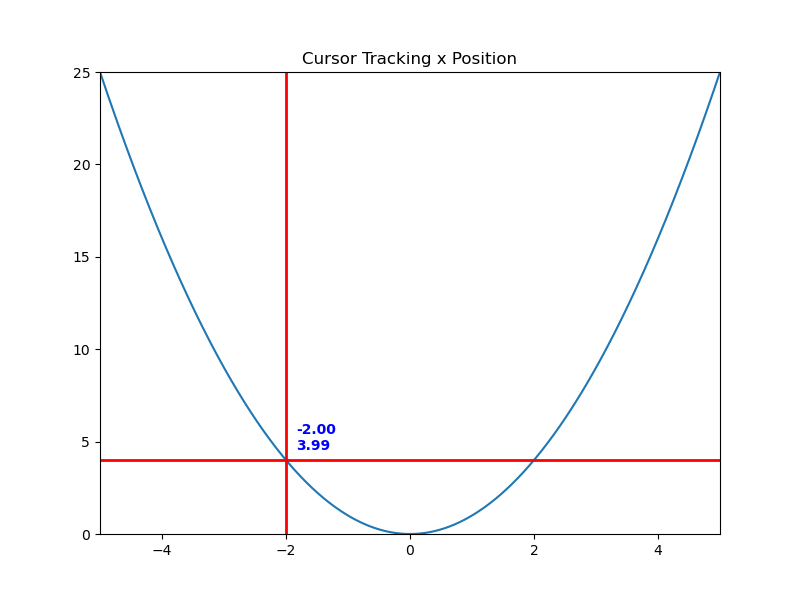

In [45]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.backend_bases import MouseEvent
from matplotlib.widgets import Cursor


class AnnotatedCursor(Cursor):
    """
    A crosshair cursor like `~matplotlib.widgets.Cursor` with a text showing \
    the current coordinates.

    For the cursor to remain responsive you must keep a reference to it.
    The data of the axis specified as *dataaxis* must be in ascending
    order. Otherwise, the `numpy.searchsorted` call might fail and the text
    disappears. You can satisfy the requirement by sorting the data you plot.
    Usually the data is already sorted (if it was created e.g. using
    `numpy.linspace`), but e.g. scatter plots might cause this problem.
    The cursor sticks to the plotted line.

    Parameters
    ----------
    line : `matplotlib.lines.Line2D`
        The plot line from which the data coordinates are displayed.

    numberformat : `python format string <https://docs.python.org/3/\
    library/string.html#formatstrings>`_, optional, default: "{0:.4g};{1:.4g}"
        The displayed text is created by calling *format()* on this string
        with the two coordinates.

    offset : (float, float) default: (5, 5)
        The offset in display (pixel) coordinates of the text position
        relative to the cross-hair.

    dataaxis : {"x", "y"}, optional, default: "x"
        If "x" is specified, the vertical cursor line sticks to the mouse
        pointer. The horizontal cursor line sticks to *line*
        at that x value. The text shows the data coordinates of *line*
        at the pointed x value. If you specify "y", it works in the opposite
        manner. But: For the "y" value, where the mouse points to, there might
        be multiple matching x values, if the plotted function is not biunique.
        Cursor and text coordinate will always refer to only one x value.
        So if you use the parameter value "y", ensure that your function is
        biunique.

    Other Parameters
    ----------------
    textprops : `matplotlib.text` properties as dictionary
        Specifies the appearance of the rendered text object.

    **cursorargs : `matplotlib.widgets.Cursor` properties
        Arguments passed to the internal `~matplotlib.widgets.Cursor` instance.
        The `matplotlib.axes.Axes` argument is mandatory! The parameter
        *useblit* can be set to *True* in order to achieve faster rendering.

    """

    def __init__(self, line, numberformat="{0:.4g};{1:.4g}", offset=(5, 5),
                 dataaxis='x', textprops=None, **cursorargs):
        if textprops is None:
            textprops = {}
        # The line object, for which the coordinates are displayed
        self.line = line
        # The format string, on which .format() is called for creating the text
        self.numberformat = numberformat
        # Text position offset
        self.offset = np.array(offset)
        # The axis in which the cursor position is looked up
        self.dataaxis = dataaxis

        # First call baseclass constructor.
        # Draws cursor and remembers background for blitting.
        # Saves ax as class attribute.
        super().__init__(**cursorargs)

        # Default value for position of text.
        self.set_position(self.line.get_xdata()[0], self.line.get_ydata()[0])
        # Create invisible animated text
        self.text = self.ax.text(
            self.ax.get_xbound()[0],
            self.ax.get_ybound()[0],
            "0, 0",
            animated=bool(self.useblit),
            visible=False, **textprops)
        # The position at which the cursor was last drawn
        self.lastdrawnplotpoint = None

    def onmove(self, event):
        """
        Overridden draw callback for cursor. Called when moving the mouse.
        """

        # Leave method under the same conditions as in overridden method
        if self.ignore(event):
            self.lastdrawnplotpoint = None
            return
        if not self.canvas.widgetlock.available(self):
            self.lastdrawnplotpoint = None
            return

        # If the mouse left drawable area, we now make the text invisible.
        # Baseclass will redraw complete canvas after, which makes both text
        # and cursor disappear.
        if event.inaxes != self.ax:
            self.lastdrawnplotpoint = None
            self.text.set_visible(False)
            super().onmove(event)
            return

        # Get the coordinates, which should be displayed as text,
        # if the event coordinates are valid.
        plotpoint = None
        if event.xdata is not None and event.ydata is not None:
            # Get plot point related to current x position.
            # These coordinates are displayed in text.
            plotpoint = self.set_position(event.xdata, event.ydata)
            # Modify event, such that the cursor is displayed on the
            # plotted line, not at the mouse pointer,
            # if the returned plot point is valid
            if plotpoint is not None:
                event.xdata = plotpoint[0]
                event.ydata = plotpoint[1]

        # If the plotpoint is given, compare to last drawn plotpoint and
        # return if they are the same.
        # Skip even the call of the base class, because this would restore the
        # background, draw the cursor lines and would leave us the job to
        # re-draw the text.
        if plotpoint is not None and plotpoint == self.lastdrawnplotpoint:
            return

        # Baseclass redraws canvas and cursor. Due to blitting,
        # the added text is removed in this call, because the
        # background is redrawn.
        super().onmove(event)

        # Check if the display of text is still necessary.
        # If not, just return.
        # This behaviour is also cloned from the base class.
        if not self.get_active() or not self.visible:
            return

        # Draw the widget, if event coordinates are valid.
        if plotpoint is not None:
            # Update position and displayed text.
            # Position: Where the event occurred.
            # Text: Determined by set_position() method earlier
            # Position is transformed to pixel coordinates,
            # an offset is added there and this is transformed back.
            temp = [event.xdata, event.ydata]
            temp = self.ax.transData.transform(temp)
            temp = temp + self.offset
            temp = self.ax.transData.inverted().transform(temp)
            self.text.set_position(temp)
            self.text.set_text(self.numberformat.format(*plotpoint))
            self.text.set_visible(self.visible)

            # Tell base class, that we have drawn something.
            # Baseclass needs to know, that it needs to restore a clean
            # background, if the cursor leaves our figure context.
            self.needclear = True

            # Remember the recently drawn cursor position, so events for the
            # same position (mouse moves slightly between two plot points)
            # can be skipped
            self.lastdrawnplotpoint = plotpoint
        # otherwise, make text invisible
        else:
            self.text.set_visible(False)

        # Draw changes. Cannot use _update method of baseclass,
        # because it would first restore the background, which
        # is done already and is not necessary.
        if self.useblit:
            self.ax.draw_artist(self.text)
            self.canvas.blit(self.ax.bbox)
        else:
            # If blitting is deactivated, the overridden _update call made
            # by the base class immediately returned.
            # We still have to draw the changes.
            self.canvas.draw_idle()

    def set_position(self, xpos, ypos):
        """
        Finds the coordinates, which have to be shown in text.

        The behaviour depends on the *dataaxis* attribute. Function looks
        up the matching plot coordinate for the given mouse position.

        Parameters
        ----------
        xpos : float
            The current x position of the cursor in data coordinates.
            Important if *dataaxis* is set to 'x'.
        ypos : float
            The current y position of the cursor in data coordinates.
            Important if *dataaxis* is set to 'y'.

        Returns
        -------
        ret : {2D array-like, None}
            The coordinates which should be displayed.
            *None* is the fallback value.
        """

        # Get plot line data
        xdata = self.line.get_xdata()
        ydata = self.line.get_ydata()

        # The dataaxis attribute decides, in which axis we look up which cursor
        # coordinate.
        if self.dataaxis == 'x':
            pos = xpos
            data = xdata
            lim = self.ax.get_xlim()
        elif self.dataaxis == 'y':
            pos = ypos
            data = ydata
            lim = self.ax.get_ylim()
        else:
            raise ValueError(f"The data axis specifier {self.dataaxis} should "
                             f"be 'x' or 'y'")

        # If position is valid and in valid plot data range.
        if pos is not None and lim[0] <= pos <= lim[-1]:
            # Find closest x value in sorted x vector.
            # This requires the plotted data to be sorted.
            index = np.searchsorted(data, pos)
            # Return none, if this index is out of range.
            if index < 0 or index >= len(data):
                return None
            # Return plot point as tuple.
            return (xdata[index], ydata[index])

        # Return none if there is no good related point for this x position.
        return None

    def clear(self, event):
        """
        Overridden clear callback for cursor, called before drawing the figure.
        """

        # The base class saves the clean background for blitting.
        # Text and cursor are invisible,
        # until the first mouse move event occurs.
        super().clear(event)
        if self.ignore(event):
            return
        self.text.set_visible(False)

    def _update(self):
        """
        Overridden method for either blitting or drawing the widget canvas.

        Passes call to base class if blitting is activated, only.
        In other cases, one draw_idle call is enough, which is placed
        explicitly in this class (see *onmove()*).
        In that case, `~matplotlib.widgets.Cursor` is not supposed to draw
        something using this method.
        """

        if self.useblit:
            super()._update()


fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Cursor Tracking x Position")

x = np.linspace(-5, 5, 1000)
y = x**2

line, = ax.plot(x, y)
ax.set_xlim(-5, 5)
ax.set_ylim(0, 25)

# A minimum call
# Set useblit=True on most backends for enhanced performance
# and pass the ax parameter to the Cursor base class.
# cursor = AnnotatedCursor(line=lin[0], ax=ax, useblit=True)

# A more advanced call. Properties for text and lines are passed.
# Watch the passed color names and the color of cursor line and text, to
# relate the passed options to graphical elements.
# The dataaxis parameter is still the default.
cursor = AnnotatedCursor(
    line=line,
    numberformat="{0:.2f}\n{1:.2f}",
    dataaxis='x', offset=[10, 10],
    textprops={'color': 'blue', 'fontweight': 'bold'},
    ax=ax,
    useblit=True,
    color='red',
    linewidth=2)

# Simulate a mouse move to (-2, 10), needed for online docs
t = ax.transData
MouseEvent(
    "motion_notify_event", ax.figure.canvas, *t.transform((-2, 10))
)._process()

plt.show()

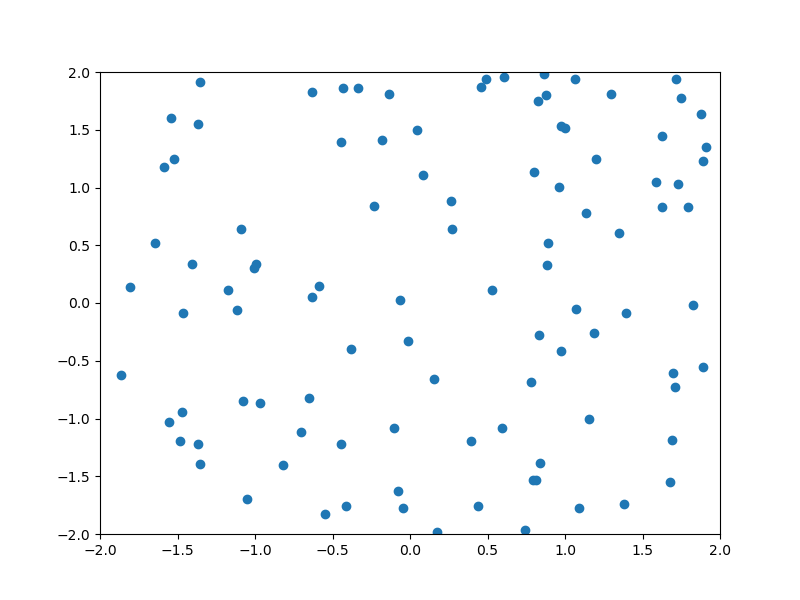

In [43]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import Cursor

# Fixing random state for reproducibility
np.random.seed(19680801)

fig, ax = plt.subplots(figsize=(8, 6))

x, y = 4*(np.random.rand(2, 100) - .5)
ax.plot(x, y, 'o')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Set useblit=True on most backends for enhanced performance.
cursor = Cursor(ax, useblit=True, color='red', linewidth=2)

plt.show()


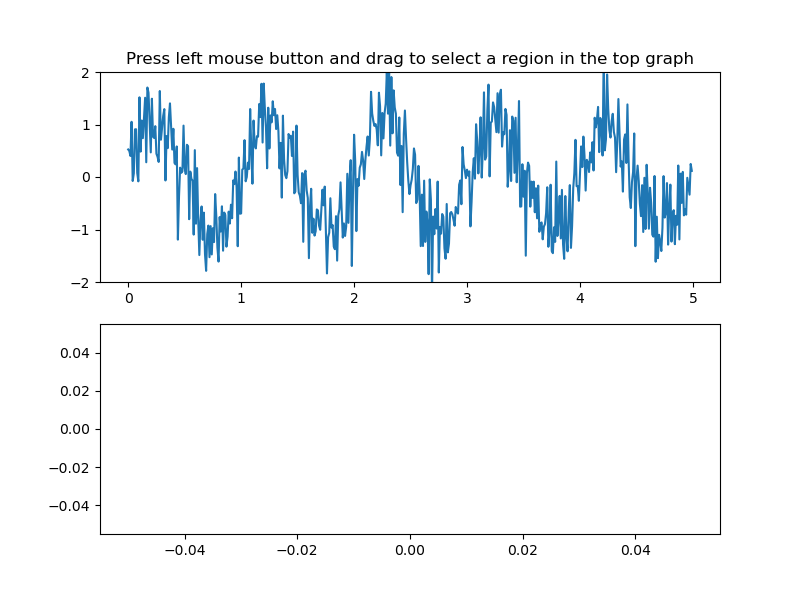

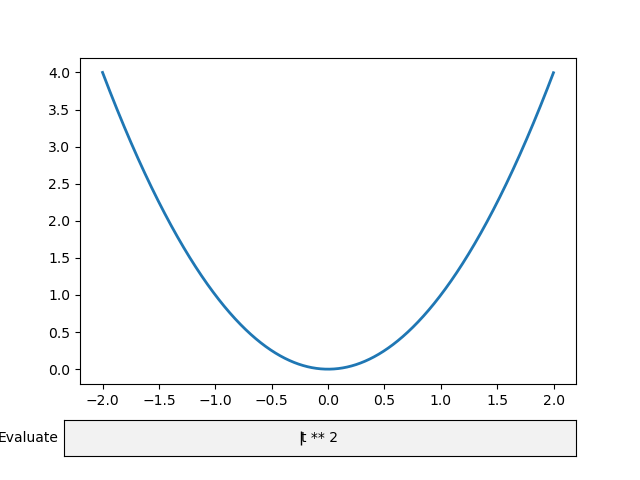

In [139]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import TextBox

fig, ax = plt.subplots()
fig.subplots_adjust(bottom=0.2)

t = np.arange(-2.0, 2.0, 0.001)
l, = ax.plot(t, np.zeros_like(t), lw=2)


def submit(expression):
    """
    Update the plotted function to the new math *expression*.

    *expression* is a string using "t" as its independent variable, e.g.
    "t ** 3".
    """
    ydata = eval(expression, {'np': np}, {'t': t})
    l.set_ydata(ydata)
    ax.relim()
    ax.autoscale_view()
    plt.draw()


axbox = fig.add_axes((0.1, 0.05, 0.8, 0.075))
text_box = TextBox(axbox, "Evaluate", textalignment="center")
text_box.on_submit(submit)
text_box.set_val("t ** 2")  # Trigger `submit` with the initial string.

plt.show()

In [14]:
["#d3d8e1", "#424348", "#24242a", "#4373cd", "#b0b0a8"]

["#365475", "#98bae3", "#5981b1", "#15273c", "#020408"]

['#365475', '#98bae3', '#5981b1', '#15273c', '#020408']

In [15]:
gated = df[selection["mask"]]
gated

NameError: name 'selection' is not defined